In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [ ]:
df1 = pd.read_csv('F1drivers_2022_2025_two_or_three_stop.csv')
df1.head()

,DriverNumber,TeamName,Position,ClassifiedPosition,GridPosition,Points,Season,EventName,EventDate,PitstopCount,...,Overtakes,DriverFastestLap_s,AvgLapTime_s,AvgSpeedTrap_kmh,TrackTemp_Mean,AirTemp_Mean,Humidity_Mean,WindSpeed_Mean,Rainfall_Amount,WeatherConditions
0,10,Pierre_Gasly,7,7.0,4,6,2025,Bahrain Grand Prix,4/13/25,2,...,9,96.531,101.323456,289.291667,31.870253,27.052532,45.329114,2.105696,0,Clear
1,10,Pierre_Gasly,13,13.0,10,0,2025,Emilia Romagna Grand Prix,5/18/25,2,...,10,80.398,87.692429,278.888889,42.664000,23.964667,38.306667,3.248000,0,Windy
2,43,Franco_Colapinto,16,16.0,16,0,2025,Emilia Romagna Grand Prix,5/18/25,2,...,11,80.345,87.723968,280.904762,42.664000,23.964667,38.306667,3.248000,0,Windy
3,43,Franco_Colapinto,13,13.0,18,0,2025,Monaco Grand Prix,5/25/25,2,...,8,75.298,80.144171,276.236842,43.317500,22.209375,52.518750,0.979375,0,Clear
4,10,Pierre_Gasly,8,8.0,8,4,2025,Spanish Grand Prix,6/1/25,3,...,12,77.896,84.776621,305.175439,48.543226,29.120000,54.625806,1.632903,0,Clear


In [ ]:
df2 = df1.drop(['DriverNumber','Season','EventName','EventDate', 'TireStrategy0'], axis = 1)
df2.head()

,TeamName,Position,ClassifiedPosition,GridPosition,Points,PitstopCount,TireStrategy,Overtakes,DriverFastestLap_s,AvgLapTime_s,AvgSpeedTrap_kmh,TrackTemp_Mean,AirTemp_Mean,Humidity_Mean,WindSpeed_Mean,Rainfall_Amount,WeatherConditions
0,Pierre_Gasly,7,7.0,4,6,2,SOFT_HARD,9,96.531,101.323456,289.291667,31.870253,27.052532,45.329114,2.105696,0,Clear
1,Pierre_Gasly,13,13.0,10,0,2,MEDIUM_HARD,10,80.398,87.692429,278.888889,42.664000,23.964667,38.306667,3.248000,0,Windy
2,Franco_Colapinto,16,16.0,16,0,2,MEDIUM_HARD,11,80.345,87.723968,280.904762,42.664000,23.964667,38.306667,3.248000,0,Windy
3,Franco_Colapinto,13,13.0,18,0,2,HARD_MEDIUM,8,75.298,80.144171,276.236842,43.317500,22.209375,52.518750,0.979375,0,Clear
4,Pierre_Gasly,8,8.0,8,4,3,SOFT_MEDIUM,12,77.896,84.776621,305.175439,48.543226,29.120000,54.625806,1.632903,0,Clear


In [ ]:
df2['TeamName'] = df2['TeamName'].astype(str)
df3 = pd.get_dummies(df2, drop_first=False) # Create all dummy variables
df3.head()

,Position,ClassifiedPosition,GridPosition,Points,PitstopCount,Overtakes,DriverFastestLap_s,AvgLapTime_s,AvgSpeedTrap_kmh,TrackTemp_Mean,...,TeamName_Yuki_Tsunoda,TireStrategy_HARD_MEDIUM,TireStrategy_HARD_SOFT,TireStrategy_MEDIUM_HARD,TireStrategy_MEDIUM_SOFT,TireStrategy_SOFT_HARD,TireStrategy_SOFT_MEDIUM,WeatherConditions_Clear,WeatherConditions_Rainy,WeatherConditions_Windy
0,7,7.0,4,6,2,9,96.531,101.323456,289.291667,31.870253,...,False,False,False,False,False,True,False,True,False,False
1,13,13.0,10,0,2,10,80.398,87.692429,278.888889,42.664000,...,False,False,False,True,False,False,False,False,False,True
2,16,16.0,16,0,2,11,80.345,87.723968,280.904762,42.664000,...,False,False,False,True,False,False,False,False,False,True
3,13,13.0,18,0,2,8,75.298,80.144171,276.236842,43.317500,...,False,True,False,False,False,False,False,True,False,False
4,8,8.0,8,4,3,12,77.896,84.776621,305.175439,48.543226,...,False,False,False,False,False,False,True,True,False,False


In [ ]:
X = df3.drop('Points', axis = 1)
y = df3['Points']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
# Creating the string for the formula
col_string = ' + '.join(X_train.columns)
col_string

'Position + ClassifiedPosition + GridPosition + PitstopCount + Overtakes + DriverFastestLap_s + AvgLapTime_s + AvgSpeedTrap_kmh + TrackTemp_Mean + AirTemp_Mean + Humidity_Mean + WindSpeed_Mean + Rainfall_Amount + TeamName_Alexander_Albon + TeamName_Carlos_Sainz + TeamName_Charles_Leclerc + TeamName_Esteban_Ocon + TeamName_Fernando_Alonso + TeamName_Franco_Colapinto + TeamName_Gabriel_Bortoleto + TeamName_George_Russell + TeamName_Isack_Hadjar + TeamName_Kimi_Antonelli + TeamName_Lance_Stroll + TeamName_Lando_Norris + TeamName_Lewis_Hamilton + TeamName_Liam_Lawson + TeamName_Max_Verstappen + TeamName_Nico_Hulkenberg + TeamName_Oliver_Bearman + TeamName_Oscar_Piastri + TeamName_Pierre_Gasly + TeamName_Yuki_Tsunoda + TireStrategy_HARD_MEDIUM + TireStrategy_HARD_SOFT + TireStrategy_MEDIUM_HARD + TireStrategy_MEDIUM_SOFT + TireStrategy_SOFT_HARD + TireStrategy_SOFT_MEDIUM + WeatherConditions_Clear + WeatherConditions_Rainy + WeatherConditions_Windy'

In [ ]:
# Linear regression model
lin_reg_model = smf.ols(formula = 'Points ~ ' + col_string, data = pd.concat([X_train, y_train], axis=1))
lin_reg_model_results = lin_reg_model.fit()
print(lin_reg_model_results.summary())

                            OLS Regression Results                            
Dep. Variable:                 Points   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     73.65
Date:                Sat, 29 Nov 2025   Prob (F-statistic):          1.12e-161
Time:                        04:19:35   Log-Likelihood:                -1132.7
No. Observations:                 461   AIC:                             2343.
Df Residuals:                     422   BIC:                             2505.
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [ ]:
# Creating varaibles to store the actual points and predictions
y_train_points = y_train.copy()
y_train_pred = lin_reg_model_results.predict(X_train)
y_test_points = y_test.copy()
y_test_pred = lin_reg_model_results.predict(X_test)

In [ ]:
# Calculating the SSE and SST, and calculate R^2 for training dataset
train_SSE = np.sum((y_train_points - y_train_pred)**2)
train_SST = np.sum((y_train_points - y_train_pred.mean())**2)
train_R2 = 1 - train_SSE/train_SST
print("Training set R^2 " + str(round(train_R2, 4)))

Training set R^2 0.8758


In [ ]:
# Calculating the SSE and SST, and calculate R^2 for test dataset
test_SSE = np.sum((y_test_points - y_test_pred)**2)
test_SST = np.sum((y_test_points - y_test_pred.mean())**2)
test_R2 = 1 - test_SSE/test_SST
print("Test set R^2 " + str(round(test_R2, 4)))

Test set R^2 0.837


In [ ]:
# Pulling out the team columns to do prediction analysis
team_cols = [col for col in X_train.columns if col.startswith('TeamName_')]
print(team_cols)

['TeamName_Alexander_Albon', 'TeamName_Carlos_Sainz', 'TeamName_Charles_Leclerc', 'TeamName_Esteban_Ocon', 'TeamName_Fernando_Alonso', 'TeamName_Franco_Colapinto', 'TeamName_Gabriel_Bortoleto', 'TeamName_George_Russell', 'TeamName_Isack_Hadjar', 'TeamName_Kimi_Antonelli', 'TeamName_Lance_Stroll', 'TeamName_Lando_Norris', 'TeamName_Lewis_Hamilton', 'TeamName_Liam_Lawson', 'TeamName_Max_Verstappen', 'TeamName_Nico_Hulkenberg', 'TeamName_Oliver_Bearman', 'TeamName_Oscar_Piastri', 'TeamName_Pierre_Gasly', 'TeamName_Yuki_Tsunoda']


In [ ]:
weather_encoded_cols = [col for col in X_train.columns if col.startswith('WeatherConditions_')]
weather_types = [col.replace('WeatherConditions_', '') for col in weather_encoded_cols]

tire_strategy_encoded_cols = [col for col in X_train.columns if col.startswith('TireStrategy_')]
tire_strategies = [col.replace('TireStrategy_', '') for col in tire_strategy_encoded_cols]

# With drop_first=False, all categories are explicitly encoded, so there is no 'base' category to infer.
# We set base_weather and base_tire_strategy to None so that the create_scenario_df function correctly
# activates the chosen dummy variable, as 'weather_type != None' will always be true for a valid weather_type.
base_weather = None
base_tire_strategy = None

print(f"All weather types: {weather_types}")
print(f"All tire strategies: {tire_strategies}")

All weather types: ['Clear', 'Rainy', 'Windy']
All tire strategies: ['HARD_MEDIUM', 'HARD_SOFT', 'MEDIUM_HARD', 'MEDIUM_SOFT', 'SOFT_HARD', 'SOFT_MEDIUM']


In [ ]:
def create_scenario_df(weather_type, tire_strategy, X_train, weather_encoded_cols, tire_strategy_encoded_cols, base_weather, base_tire_strategy):
    # Create a new DataFrame called scenario_df by calculating the mean of each column in X_train
    scenario_df = pd.DataFrame(X_train.mean()).T

    # Iterate through weather_encoded_cols and set the corresponding columns in scenario_df to False.
    for col in weather_encoded_cols:
        scenario_df[col] = False

    # Iterate through tire_strategy_encoded_cols and set the corresponding columns in scenario_df to False.
    for col in tire_strategy_encoded_cols:
        scenario_df[col] = False

    # If the provided weather_type is not equal to the base_weather, set the column f'WeatherConditions_{weather_type}' in scenario_df to True.
    if weather_type != base_weather:
        weather_col_name = f'WeatherConditions_{weather_type}'
        if weather_col_name in scenario_df.columns:
            scenario_df[weather_col_name] = True

    # If the provided tire_strategy is not equal to the base_tire_strategy, set the column f'TireStrategy_{tire_strategy}' in scenario_df to True.
    if tire_strategy != base_tire_strategy:
        tire_strategy_col_name = f'TireStrategy_{tire_strategy}'
        if tire_strategy_col_name in scenario_df.columns:
            scenario_df[tire_strategy_col_name] = True

    # After setting the boolean flags, iterate through all columns in scenario_df and explicitly cast each column to match the data type of its corresponding column in X_train.
    for col in scenario_df.columns:
        if col in X_train.columns:
            scenario_df[col] = scenario_df[col].astype(X_train[col].dtype)

    return scenario_df

In [ ]:
prediction_matrices = {}

# Get unique team names
unique_team_names = [col.replace('TeamName_', '') for col in team_cols]

for current_weather_type in weather_types:
    # Create an empty DataFrame for the current weather type
    weather_matrix = pd.DataFrame(index=unique_team_names, columns=tire_strategies)

    for current_tire_strategy in tire_strategies:
        # Generate a base scenario DataFrame for the current weather and tire strategy
        base_scenario_df = create_scenario_df(
            current_weather_type,
            current_tire_strategy,
            X_train,
            weather_encoded_cols,
            tire_strategy_encoded_cols,
            base_weather,
            base_tire_strategy
        )

        team_predictions = {}
        for team_col in team_cols:
            # Create a copy of the base scenario for each team
            scenario_for_team = base_scenario_df.copy()

            # Set the current team's one-hot encoded column to True
            scenario_for_team[team_col] = True

            # Set all other team columns to False
            for other_team_col in team_cols:
                if other_team_col != team_col:
                    scenario_for_team[other_team_col] = False

            # Predict points for the current team scenario
            predicted_points = lin_reg_model_results.predict(scenario_for_team)[0]
            team_name = team_col.replace('TeamName_', '')
            team_predictions[team_name] = predicted_points

        # Populate the weather_matrix for the current tire strategy column
        weather_matrix[current_tire_strategy] = pd.Series(team_predictions)

    # Store the completed weather matrix
    prediction_matrices[current_weather_type] = weather_matrix

In [ ]:
# Print each prediction matrix with a descriptive header, sorted by maximum predicted points per driver
for weather, matrix in prediction_matrices.items():
    print(f"\nPrediction Matrix for {weather} Weather (Sorted by Max Points):")

    # Calculate the maximum predicted points for each driver across all tire strategies
    # This will be used for sorting the drivers (rows)
    matrix_with_max_points = matrix.copy()
    matrix_with_max_points['Max_Predicted_Points'] = matrix_with_max_points.max(axis=1)

    # Sort the matrix by the 'Max_Predicted_Points' column in descending order
    sorted_matrix = matrix_with_max_points.sort_values(by='Max_Predicted_Points', ascending=False)

    # Drop the temporary 'Max_Predicted_Points' column before printing
    sorted_matrix = sorted_matrix.drop(columns=['Max_Predicted_Points'])

    print(sorted_matrix.round(2))


Prediction Matrix for Clear Weather (Sorted by Max Points):
                   HARD_MEDIUM  HARD_SOFT  MEDIUM_HARD  MEDIUM_SOFT  \
Max_Verstappen           11.16      11.96        11.49        12.20   
Lando_Norris              7.03       7.84         7.36         8.07   
Charles_Leclerc           6.80       7.60         7.13         7.84   
Kimi_Antonelli            6.74       7.55         7.08         7.78   
Oscar_Piastri             6.68       7.48         7.01         7.72   
Lewis_Hamilton            6.63       7.43         6.96         7.67   
Carlos_Sainz              6.49       7.30         6.82         7.53   
Franco_Colapinto          6.08       6.88         6.41         7.12   
Isack_Hadjar              6.07       6.88         6.41         7.11   
George_Russell            5.85       6.65         6.18         6.88   
Gabriel_Bortoleto         5.83       6.64         6.17         6.87   
Nico_Hulkenberg           5.82       6.63         6.16         6.86   
Lance_Stroll    

In [ ]:
for weather, matrix in prediction_matrices.items():
    print(f"\nTop-performing teams for {weather} Weather:")
    if matrix.empty:
        print("  No predictions available for this weather type as the prediction matrix is empty.")
        continue
    # Iterate through each tire strategy (column) to find the max points and corresponding team
    for strategy in matrix.columns:
        # Check if the column (Series) is empty before calling idxmax()
        if not matrix[strategy].empty:
            top_team_idx = matrix[strategy].idxmax()
            max_points = matrix[strategy].max()
            print(f"  {strategy}: {top_team_idx} with {max_points:.2f} points")
        else:
            print(f"  No predictions for strategy {strategy} as the column is empty.")


Top-performing teams for Clear Weather:
  HARD_MEDIUM: Max_Verstappen with 11.16 points
  HARD_SOFT: Max_Verstappen with 11.96 points
  MEDIUM_HARD: Max_Verstappen with 11.49 points
  MEDIUM_SOFT: Max_Verstappen with 12.20 points
  SOFT_HARD: Max_Verstappen with 10.63 points
  SOFT_MEDIUM: Max_Verstappen with 12.69 points

Top-performing teams for Rainy Weather:
  HARD_MEDIUM: Max_Verstappen with 10.13 points
  HARD_SOFT: Max_Verstappen with 10.94 points
  MEDIUM_HARD: Max_Verstappen with 10.47 points
  MEDIUM_SOFT: Max_Verstappen with 11.17 points
  SOFT_HARD: Max_Verstappen with 9.60 points
  SOFT_MEDIUM: Max_Verstappen with 11.66 points

Top-performing teams for Windy Weather:
  HARD_MEDIUM: Max_Verstappen with 10.98 points
  HARD_SOFT: Max_Verstappen with 11.79 points
  MEDIUM_HARD: Max_Verstappen with 11.32 points
  MEDIUM_SOFT: Max_Verstappen with 12.02 points
  SOFT_HARD: Max_Verstappen with 10.45 points
  SOFT_MEDIUM: Max_Verstappen with 12.51 points


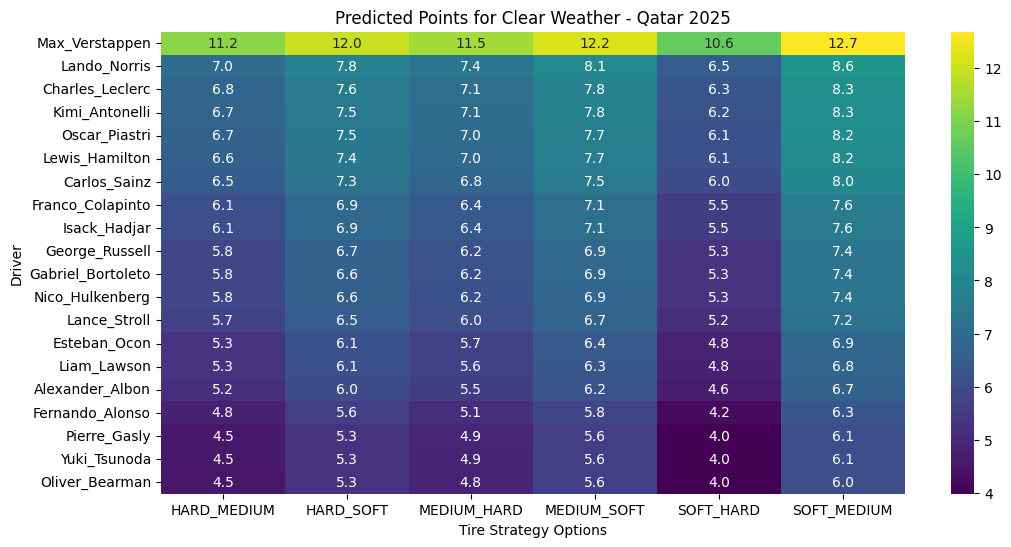

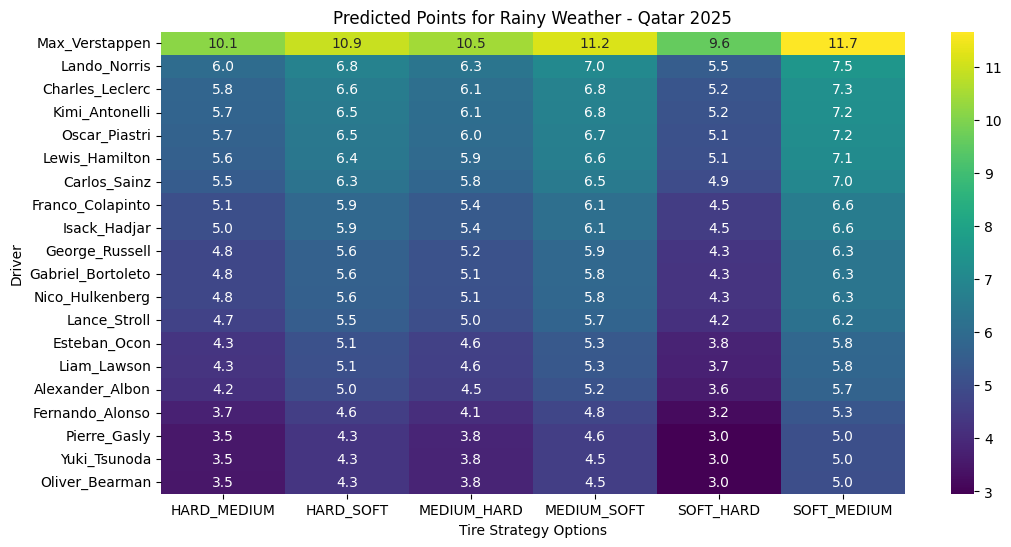

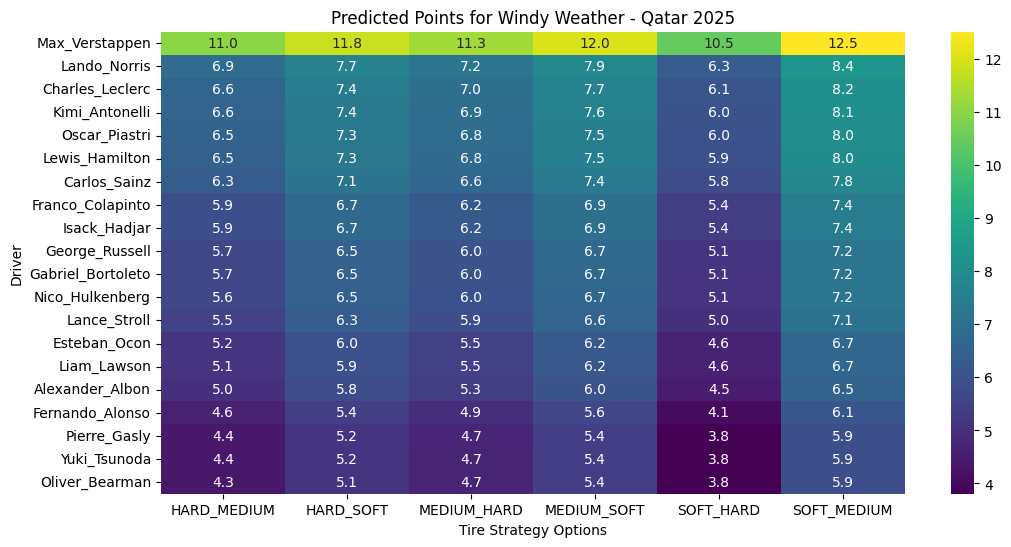

In [ ]:
for weather, matrix in prediction_matrices.items():
    # Calculate the maximum predicted points for each driver across all tire strategies
    matrix_with_max_points = matrix.copy()
    matrix_with_max_points['Max_Predicted_Points'] = matrix_with_max_points.max(axis=1)

    # Sort the matrix by the 'Max_Predicted_Points' column in descending order
    sorted_matrix_by_driver = matrix_with_max_points.sort_values(by='Max_Predicted_Points', ascending=False)

    # Drop the temporary 'Max_Predicted_Points' column
    sorted_matrix_by_driver = sorted_matrix_by_driver.drop(columns=['Max_Predicted_Points'])

    # Sort the columns (tire strategies) alphabetically for consistent plot layout
    sorted_columns = sorted(sorted_matrix_by_driver.columns)
    matrix_to_plot = sorted_matrix_by_driver[sorted_columns]

    plt.figure(figsize=(12, 6))
    sns.heatmap(matrix_to_plot, annot=True, fmt=".1f", cmap="viridis")
    plt.title(f'Predicted Points for {weather} Weather - Qatar 2025')
    plt.xlabel('Tire Strategy Options')
    plt.ylabel('Driver')
    plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate MSE, RMSE, and MAE for the training set
# Filter out NaN values from both actual and predicted points
valid_train_indices = ~np.isnan(y_train_points) & ~np.isnan(y_train_pred)
train_mse = mean_squared_error(y_train_points[valid_train_indices], y_train_pred[valid_train_indices])
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train_points[valid_train_indices], y_train_pred[valid_train_indices])

print(f"Training MSE: {train_mse:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Training MAE: {train_mae:.4f}")

Training MSE: 7.9742
Training RMSE: 2.8239
Training MAE: 2.1935


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate MSE, RMSE, and MAE for the test set
# Filter out NaN values from both actual and predicted points
valid_test_indices = ~np.isnan(y_test_points) & ~np.isnan(y_test_pred)
test_mse = mean_squared_error(y_test_points[valid_test_indices], y_test_pred[valid_test_indices])
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_points[valid_test_indices], y_test_pred[valid_test_indices])

print(f"Test MSE: {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test MSE: 9.9860
Test RMSE: 3.1601
Test MAE: 2.5095


In [ ]:
SSE = np.sum((y_test - y_test_pred)**2)
print(SSE)

1178.3437658430432


In [ ]:
SST = np.sum((y_test - df3['Points'].mean())**2)
print(SST)
R2 = 1 - SSE/SST
print(R2)

7252.41577905552
0.837523964187765
